**New York City Airbnb 2019 EDA**

**1. importing necessary libraries**

In [49]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor


**2. reading csv file and exploring various aspects of the dataset**

In [26]:
df = pd.read_csv('AB_NYC_2019.csv')


In [10]:
df.shape

(48895, 16)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

- Target variable is price
- Several columns are of object type - either need to convert to date/time, drop, label/hot encode

In [5]:
#statistical analysis
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


**3. data cleaning**

In [18]:
df['neighbourhood'].value_counts()  #too many, drop this column

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Richmondtown             1
Fort Wadsworth           1
New Dorp                 1
Rossville                1
Willowbrook              1
Name: count, Length: 221, dtype: int64

In [ ]:
df['neighbourhood_group'].value_counts()   
#one hot encoding as only 5 unique values


neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

In [ ]:
df['room_type'].value_counts()   #one hot encode as only 3 unique values

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

In [27]:
ohe_cols = ['neighbourhood_group', 'room_type']
ohe = OneHotEncoder(handle_unknown='error', sparse_output=False).set_output(transform='pandas')
ohe_tranformed = ohe.fit_transform(df[ohe_cols])
ohe_tranformed

,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
48890,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
48891,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
48892,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
48893,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [28]:
data = df.copy()
data = pd.concat([data, ohe_tranformed], axis=1).drop(columns = ohe_cols)
data.head()

,id,name,host_id,host_name,neighbourhood,latitude,longitude,price,minimum_nights,number_of_reviews,...,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
0,2539,Clean & quiet apt home by the park,2787,John,Kensington,40.64749,-73.97237,149,1,9,...,6,365,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2595,Skylit Midtown Castle,2845,Jennifer,Midtown,40.75362,-73.98377,225,1,45,...,2,355,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Harlem,40.80902,-73.94190,150,3,0,...,1,365,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Clinton Hill,40.68514,-73.95976,89,1,270,...,1,194,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,East Harlem,40.79851,-73.94399,80,10,9,...,1,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [29]:
#will drop name, hostname and id as they have no purpose 
data.drop(columns=['id','host_id', 'name', 'host_name', 'neighbourhood'], inplace=True)
data.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
0,40.64749,-73.97237,149,1,9,2018-10-19,0.21,6,365,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,40.75362,-73.98377,225,1,45,2019-05-21,0.38,2,355,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,40.80902,-73.94190,150,3,0,NaN,NaN,1,365,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,40.68514,-73.95976,89,1,270,2019-07-05,4.64,1,194,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,40.79851,-73.94399,80,10,9,2018-11-19,0.10,1,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [30]:
data['last_review'].value_counts()  #convert to date/time
data['last_review'] = pd.to_datetime(data['last_review'], format='%Y-%m-%d')
data.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
0,40.64749,-73.97237,149,1,9,2018-10-19,0.21,6,365,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,40.75362,-73.98377,225,1,45,2019-05-21,0.38,2,355,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,40.80902,-73.94190,150,3,0,NaT,NaN,1,365,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,40.68514,-73.95976,89,1,270,2019-07-05,4.64,1,194,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,40.79851,-73.94399,80,10,9,2018-11-19,0.10,1,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [32]:
#handling missing values
data.isnull().sum()

latitude                                 0
longitude                                0
price                                    0
minimum_nights                           0
number_of_reviews                        0
last_review                          10052
reviews_per_month                    10052
calculated_host_listings_count           0
availability_365                         0
neighbourhood_group_Bronx                0
neighbourhood_group_Brooklyn             0
neighbourhood_group_Manhattan            0
neighbourhood_group_Queens               0
neighbourhood_group_Staten Island        0
room_type_Entire home/apt                0
room_type_Private room                   0
room_type_Shared room                    0
dtype: int64

In [33]:
#filling reviews_per_month with 0 where number_of_reviews is 0
data.loc[data['number_of_reviews'] == 0, 'reviews_per_month'] = 0
data.isnull().sum()

latitude                                 0
longitude                                0
price                                    0
minimum_nights                           0
number_of_reviews                        0
last_review                          10052
reviews_per_month                        0
calculated_host_listings_count           0
availability_365                         0
neighbourhood_group_Bronx                0
neighbourhood_group_Brooklyn             0
neighbourhood_group_Manhattan            0
neighbourhood_group_Queens               0
neighbourhood_group_Staten Island        0
room_type_Entire home/apt                0
room_type_Private room                   0
room_type_Shared room                    0
dtype: int64

In [34]:
#last_review is 0 since there are no reviews for that airbnb, filling it with a placeholder value and making a boolen has_last_review
data['last_review'].fillna(pd.Timestamp("1900-01-01"), inplace=True)
data['has_review'] = (data['number_of_reviews'] > 0).astype(int)

C:\Users\hibaf\AppData\Local\Temp\ipykernel_29996\3495544899.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['last_review'].fillna(pd.Timestamp("1900-01-01"), inplace=True)


In [35]:
#feature engineering: days_since_last_review to make a numerical signal
max_date = data['last_review'].max()
data['days_since_last_review'] = (max_date - data['last_review']).dt.days
data.drop(columns=['last_review'], inplace=True)
data.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room,has_review,days_since_last_review
0,40.64749,-73.97237,149,1,9,0.21,6,365,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1,262
1,40.75362,-73.98377,225,1,45,0.38,2,355,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1,48
2,40.80902,-73.94190,150,3,0,0.00,1,365,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,43652
3,40.68514,-73.95976,89,1,270,4.64,1,194,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1,3
4,40.79851,-73.94399,80,10,9,0.10,1,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1,231


In [40]:
#to avoid dummy variable trap (perfect collinearity) - dropping one dummy column from each group
data.drop(columns=['neighbourhood_group_Manhattan','room_type_Entire home/apt'], inplace=True)

In [41]:
#verifying no more null values
data.isnull().sum()

latitude                             0
longitude                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
reviews_per_month                    0
calculated_host_listings_count       0
availability_365                     0
neighbourhood_group_Bronx            0
neighbourhood_group_Brooklyn         0
neighbourhood_group_Queens           0
neighbourhood_group_Staten Island    0
room_type_Private room               0
room_type_Shared room                0
has_review                           0
days_since_last_review               0
dtype: int64

In [42]:
#dealing with duplicate rows and dropping unnecessary columns

data.duplicated().sum() #no duplicates found

np.int64(0)

- checking correlation

In [46]:
corr = data.corr()['price']
corr.sort_values(ascending=False)

price                                1.000000
days_since_last_review               0.085391
availability_365                     0.081829
calculated_host_listings_count       0.057472
minimum_nights                       0.042799
latitude                             0.033939
neighbourhood_group_Staten Island   -0.013840
neighbourhood_group_Bronx           -0.041030
number_of_reviews                   -0.047954
reviews_per_month                   -0.050564
room_type_Shared room               -0.053613
neighbourhood_group_Queens          -0.080205
has_review                          -0.085151
neighbourhood_group_Brooklyn        -0.098603
longitude                           -0.150019
room_type_Private room              -0.240246
Name: price, dtype: float64

direct linear correlation is very low

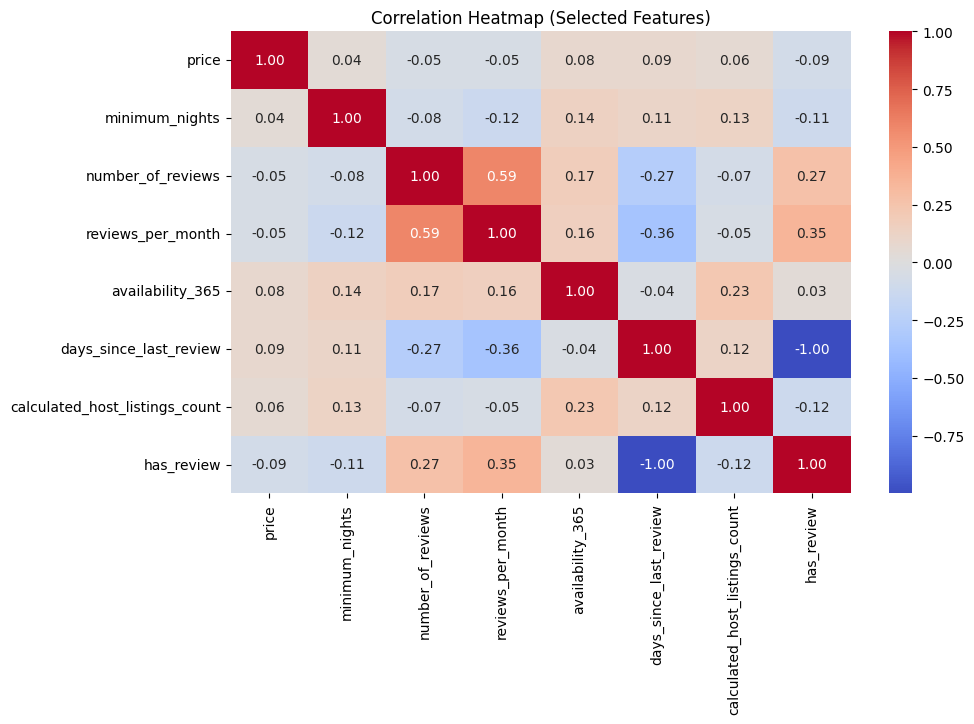

In [53]:
cols = ['price', 'minimum_nights', 'number_of_reviews',
        'reviews_per_month', 'availability_365', 'days_since_last_review', 'calculated_host_listings_count', 'has_review']
plt.figure(figsize=(10,6))
sns.heatmap(data[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Selected Features)')
plt.show()

- VIF to check multicollinearity

In [50]:
X = data.drop(columns=['price'])
vif = pd.DataFrame()

In [54]:
vif["Features"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
vif

,Features,VIF
0,latitude,1.002840e+06
1,longitude,1.016421e+06
2,minimum_nights,1.190974e+00
3,number_of_reviews,2.003358e+00
4,reviews_per_month,2.774670e+00
5,calculated_host_listings_count,1.187475e+00
6,availability_365,2.099438e+00
7,neighbourhood_group_Bronx,1.289708e+00
8,neighbourhood_group_Brooklyn,3.235008e+00
9,neighbourhood_group_Queens,1.344982e+00


multicollinearity is extremely high for latitute and longitude: dropping latitude and longitude because do not represent distance in a linear way. Instead, I will create a single feature: distance to Times Square, which captures location effect more meaningfully for linear regression. This keeps the geographic signal while improving model stability and interpretability.

Also dropping has_review since days_since_last_review offers similar insights

In [55]:
# Times Square coordinates
center_lat = 40.7580
center_lon = -73.9855

# Create distance to Times Square feature
data['distance_center'] = ((data['latitude'] - center_lat)**2 + 
                           (data['longitude'] - center_lon)**2)**0.5

# Drop raw lat/long and redundant has_review column
data.drop(columns=['latitude','longitude','has_review'], inplace=True)
data.head()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room,days_since_last_review,distance_center
0,149,1,9,0.21,6,365,0.0,1.0,0.0,0.0,1.0,0.0,262,0.111287
1,225,1,45,0.38,2,355,0.0,0.0,0.0,0.0,0.0,0.0,48,0.004709
2,150,3,0,0.00,1,365,0.0,0.0,0.0,0.0,1.0,0.0,43652,0.067112
3,89,1,270,4.64,1,194,0.0,1.0,0.0,0.0,0.0,0.0,3,0.077273
4,80,10,9,0.10,1,0,0.0,0.0,0.0,0.0,0.0,0.0,231,0.058001


In [57]:
Y = data.drop(columns=['price'])
vif2 = pd.DataFrame()
vif2["Features"] = Y.columns
vif2["VIF"] = [variance_inflation_factor(Y.values, i) for i in range(len(Y.columns))]
vif2

,Features,VIF
0,minimum_nights,1.160336
1,number_of_reviews,1.991201
2,reviews_per_month,2.367970
3,calculated_host_listings_count,1.161550
4,availability_365,1.918397
5,neighbourhood_group_Bronx,1.247809
6,neighbourhood_group_Brooklyn,2.753300
7,neighbourhood_group_Queens,1.967975
8,neighbourhood_group_Staten Island,1.171932
9,room_type_Private room,1.814206


- Fixing skew of numeric variables

In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   price                              48895 non-null  int64  
 1   minimum_nights                     48895 non-null  int64  
 2   number_of_reviews                  48895 non-null  int64  
 3   reviews_per_month                  48895 non-null  float64
 4   calculated_host_listings_count     48895 non-null  int64  
 5   availability_365                   48895 non-null  int64  
 6   neighbourhood_group_Bronx          48895 non-null  float64
 7   neighbourhood_group_Brooklyn       48895 non-null  float64
 8   neighbourhood_group_Queens         48895 non-null  float64
 9   neighbourhood_group_Staten Island  48895 non-null  float64
 10  room_type_Private room             48895 non-null  float64
 11  room_type_Shared room              48895 non-null  flo

In [60]:
num_cols = ['price','minimum_nights','number_of_reviews','reviews_per_month',
      'availability_365','days_since_last_review','distance_center',
      'calculated_host_listings_count']

skew_vals = data[num_cols].skew()
skew_vals.sort_values(ascending=False)


minimum_nights                    21.827275
price                             19.118939
calculated_host_listings_count     7.933174
number_of_reviews                  3.690635
reviews_per_month                  3.300723
days_since_last_review             1.455469
distance_center                    1.307497
availability_365                   0.763408
dtype: float64

<Axes: xlabel='price', ylabel='Count'>

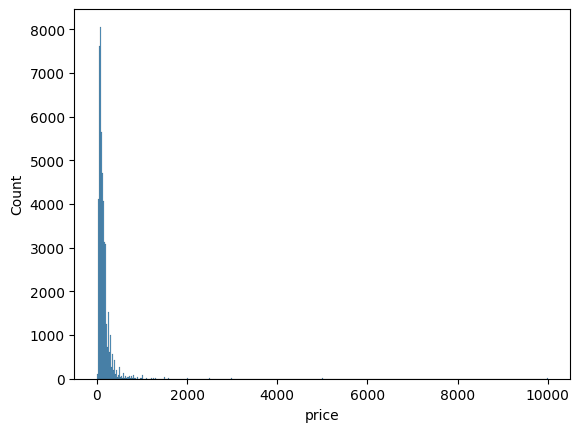

In [64]:
sns.histplot(data=data['price'])

#### 4. EDA
**a. univariate analysis**

price analysis

<Axes: ylabel='price'>

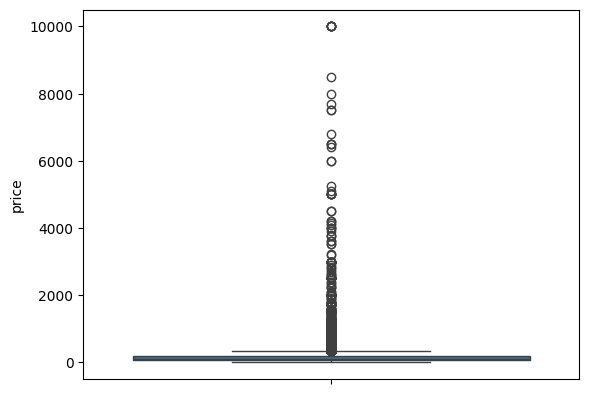

In [ ]:
#identifying outliers for price
sns.boxplot(df['price'])

# even though many "circles" i.e.  outliers exist above around 1000, distribution is dense and almost uniform until approx 1000
# removing all values above 1000 would cut a significant amount of rows for ml model


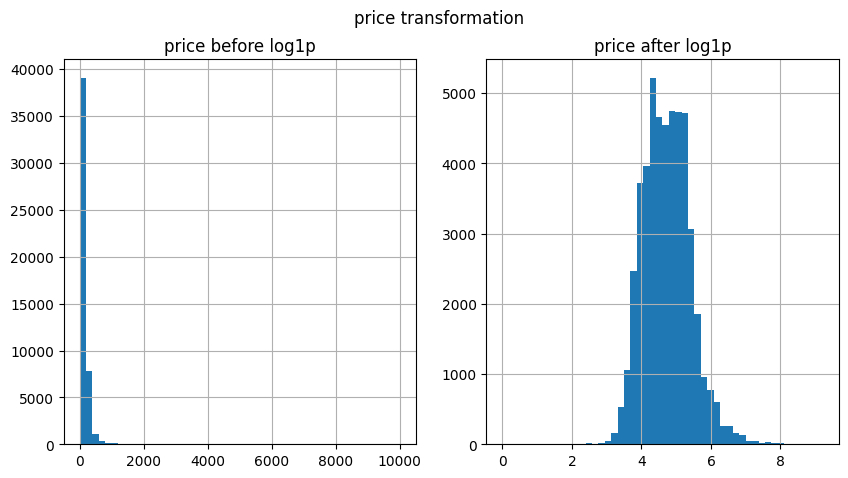

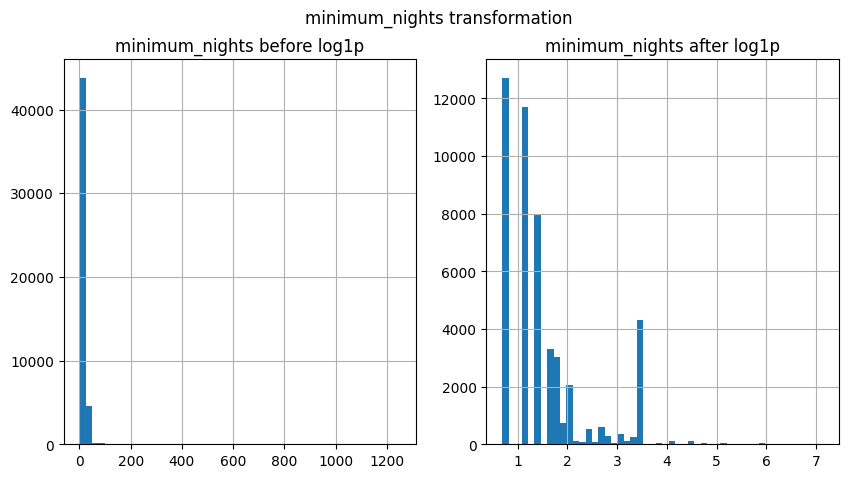

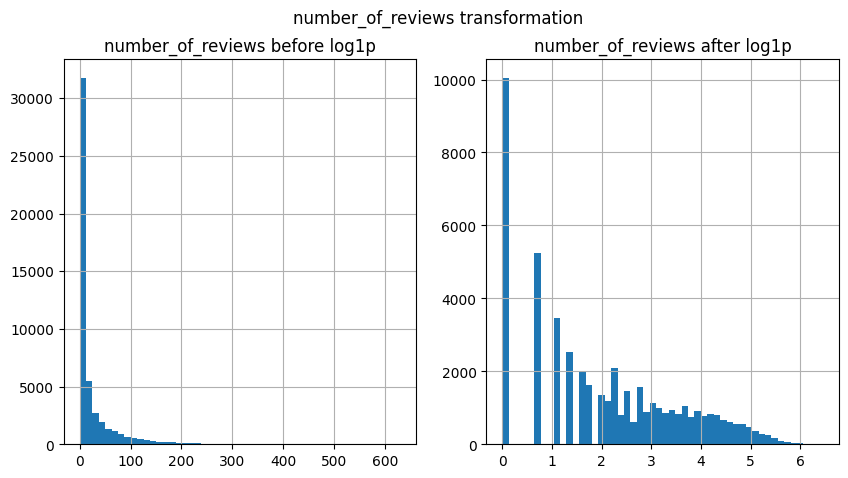

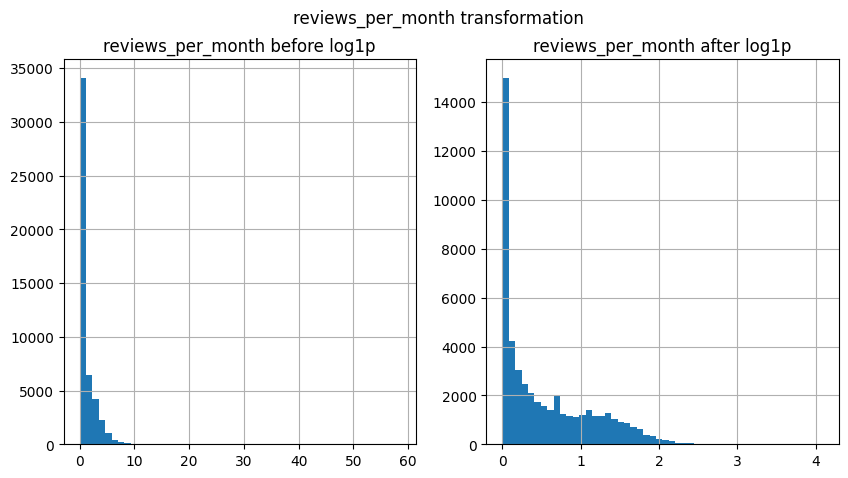

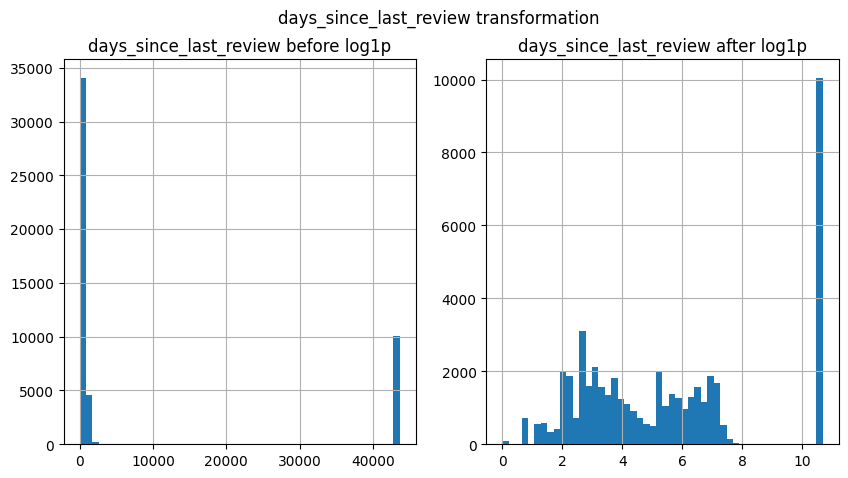

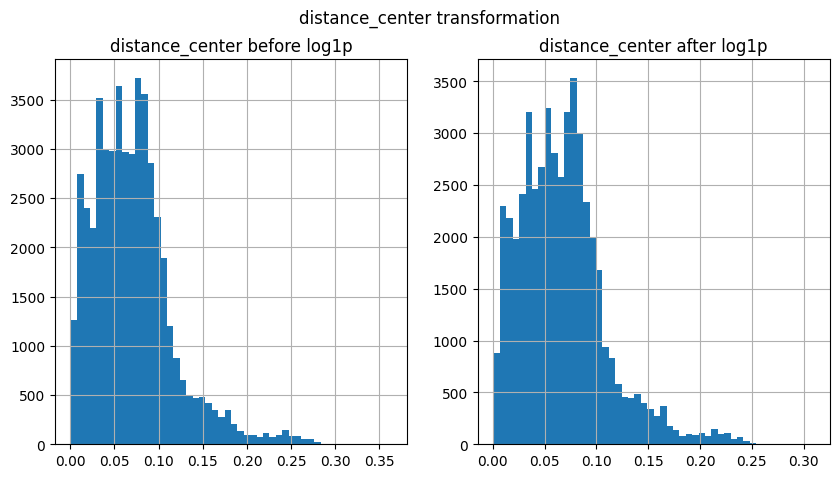

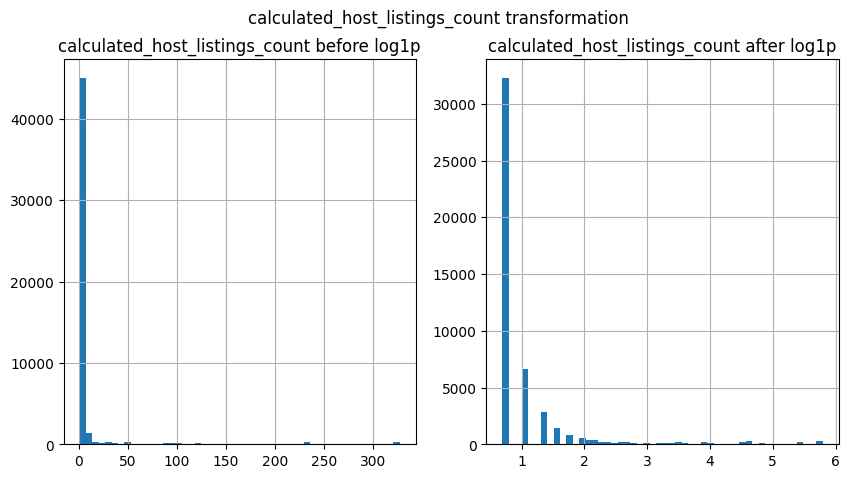

In [69]:
log_cols = ['price','minimum_nights','number_of_reviews','reviews_per_month',
      'days_since_last_review','distance_center',
      'calculated_host_listings_count']

for col in log_cols:
    fig, (ax_before, ax_after) = plt.subplots(1,2,figsize=(10,5))

    data[col].hist(ax=ax_before, bins=50)
    data[col].apply(np.log1p).hist(ax=ax_after, bins=50)

    ax_before.set(title="{} before log1p".format(col))
    ax_after.set(title="{} after log1p".format(col))
    fig.suptitle("{} transformation".format(col))

In [70]:
for col in log_cols:
    data[col] = np.log1p(data[col])

In [71]:
data[log_cols].skew().sort_values(ascending=False)

calculated_host_listings_count    3.279837
minimum_nights                    1.498510
distance_center                   1.124101
reviews_per_month                 0.950423
price                             0.553105
days_since_last_review            0.528528
number_of_reviews                 0.362924
dtype: float64

**b. bivariate analysis**

i. room type vs price: which room types are more expensive?

Text(0.5, 1.0, 'room_type vs price')

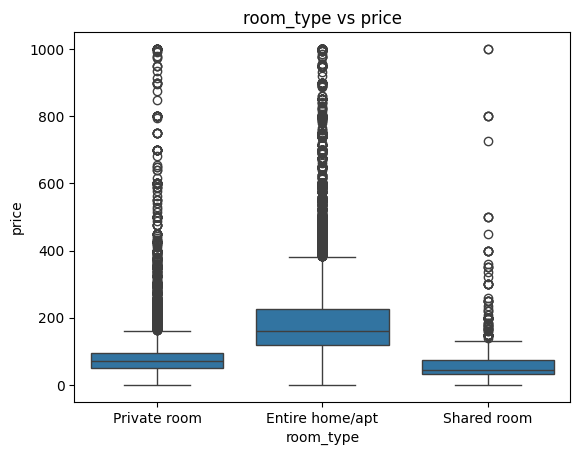

In [37]:
sns.boxplot(data=df_filtered, x='room_type', y='price')
plt.title("room_type vs price")

Text(0.5, 1.0, 'room_type vs price')

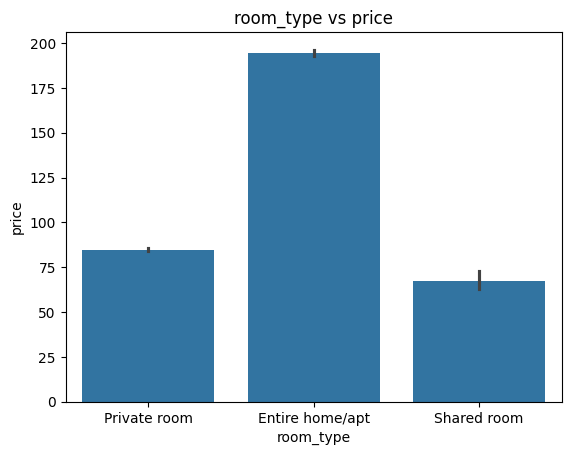

In [38]:
sns.barplot(data=df_filtered, x='room_type', y='price')
plt.title("room_type vs price")

the barplot shows that entire home/apt has the highest average price, while private room and shared room have significantly lower average price. the box plot offers more details, showing that entire home/apt have much wider range of prices as well. private rooms are cheaper and clustered tightly. finally, shared rooms are the cheapest with minimal variation and outliers.

ii. neighborhood group vs price: how does price vary with different neighborhood groups, and does room type play a role?

<Axes: xlabel='neighbourhood_group', ylabel='price'>

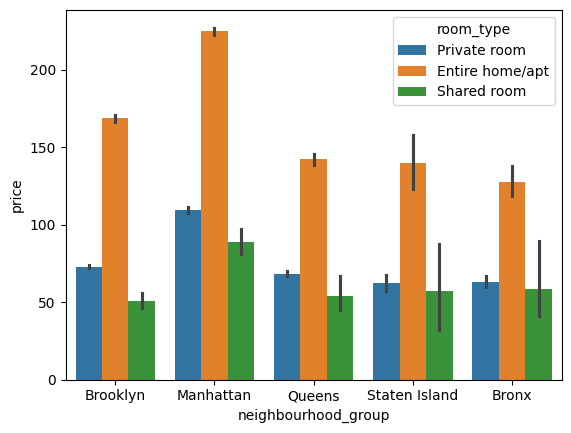

In [40]:
sns.barplot(data=df_filtered, x='neighbourhood_group', y='price', hue='room_type')

the barplot shows that manhattan is the most expensive for all room types. in every neighbourhood group, entire homes are the most expensive, with private being slightly more or equally expensive as shared rooms. queens, staten island and bronx have very similar pricing.

iii. number of reviews vs price: is there any correlation between price and number of reviews?

Text(0.5, 1.0, 'locality and review dependency')

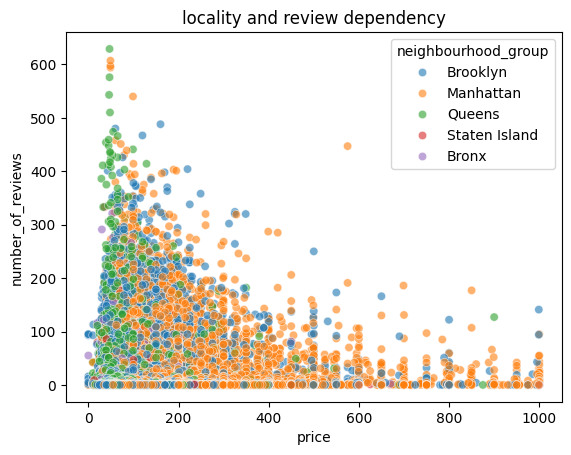

In [44]:
sns.scatterplot(data=df_filtered, x='price', y='number_of_reviews', hue='neighbourhood_group', alpha=0.6)
plt.title("locality and review dependency")

the scatterplot shows that airbnb's that cost < 200 have the greatest number of reviews. highly reviewed listings are generally more affordable. as the price increases, number of reviews decreases, suggesting either fewer bookings or a niche market.

iv. geographical location and room types: which locations are more popular for specific room types?

<Axes: xlabel='longitude', ylabel='latitude'>

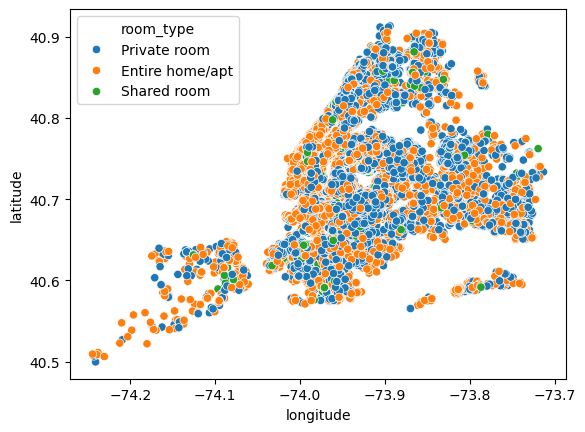

In [43]:
sns.scatterplot(data=df, x='longitude', y='latitude', hue='room_type')

orange (entire home) is dominant across almost all areas. blue (private rooms) are also widespread and common. green can be seen rarely and are the least common.

***hypothesis testing***

3 hypothesis:
1. Listings located closer to Times Square have significantly higher prices.
2. Listings with more reviews tend to have lower prices.
3. Entire home/apt listings have significantly higher average prices than private or shared rooms.

- Testing hypothesis 3: Entire home/apt listings have significantly higher average prices than private or shared rooms.

Null hypothesis: Mean price of entire apt = Mean price of private rooms
Alternate: Mean price of entire apt > Mean price of private rooms

In [72]:
from scipy.stats import ttest_ind

# Separate the two groups
entire = df[df['room_type'] == 'Entire home/apt']['price']
private = df[df['room_type'] == 'Private room']['price']

# Two-sample t-test (Welch's t-test since variance likely unequal)
t_stat, p_two_tailed = ttest_ind(entire, private, equal_var=False)

# Convert to one-tailed test (H1: Entire home > Private room)
if t_stat > 0:
    p_one_tailed = p_two_tailed / 2
else:
    p_one_tailed = 1 - (p_two_tailed / 2)

print("Mean (Entire home):", entire.mean())
print("Mean (Private room):", private.mean())
print("T-statistic:", t_stat)
print("Two-tailed p-value:", p_two_tailed)
print("One-tailed p-value:", p_one_tailed)

Mean (Entire home): 211.79424613325986
Mean (Private room): 89.78097285675894
T-statistic: 58.67088986448112
Two-tailed p-value: 0.0
One-tailed p-value: 0.0


since p < 0.05, there is overwhelming statistical evidence that entire home listings on Airbnb are more expensive than private rooms.
